# Sentiment Validation

Notebook ini dipakai untuk menjawab satu pertanyaan sederhana: **apakah news sentiment layak dipakai sebagai sinyal jangka pendek untuk harga aluminium?**

**Cara membaca notebook ini**
- Sentiment di sini berarti **dampak berita ke harga aluminium**, bukan sentimen umum positif/negatif.
- Input berita yang dipakai hanya artikel **`candidate_model`** hasil seleksi dari `EDA-NEWS`.
- Evaluasi harga memakai **raw price series** agar tanggal trading lebih lengkap.
- Horizon yang dipakai adalah **trading day**, bukan kalender:
  - `T+1` = 1 trading day ke depan
  - `T+3` = 3 trading day ke depan
  - `T+5` = 5 trading day ke depan (kurang lebih 1 minggu trading)

**Tujuan notebook ini**
1. Audit hasil scoring artikel
2. Lihat agregasi sentiment harian
3. Cek apakah sentiment harian searah dengan return jangka pendek
4. Putuskan apakah news lebih cocok sebagai **explanation**, **overlay**, atau **feature model**


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_colwidth', 140)
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SCORED_PATH = PROJECT_ROOT / 'data/news/scored/gdelt_candidate_model_scored_v1.csv'
DAILY_PATH = PROJECT_ROOT / 'data/news/features/gdelt_daily_sentiment_features_v1.csv'
PRICE_PATH = PROJECT_ROOT / 'data/raw data/ali_f_raw.csv'

assert SCORED_PATH.exists(), f'Tidak menemukan file: {SCORED_PATH}'
assert DAILY_PATH.exists(), f'Tidak menemukan file: {DAILY_PATH}'
assert PRICE_PATH.exists(), f'Tidak menemukan file: {PRICE_PATH}'

scored = pd.read_csv(SCORED_PATH, parse_dates=['news_date', 'news_datetime', 'scored_at_utc'])
daily = pd.read_csv(DAILY_PATH, parse_dates=['news_date'])
price = pd.read_csv(PRICE_PATH, parse_dates=['Date'])[['Date', 'Close']].sort_values('Date').dropna()

for horizon in [1, 3, 5]:
    price[f'close_t{horizon}'] = price['Close'].shift(-horizon)
    price[f'ret_t{horizon}'] = price[f'close_t{horizon}'] / price['Close'] - 1


In [2]:
overview = pd.DataFrame(
    [
        ('Artikel kandidat yang sudah discore', len(scored), 'Semua artikel yang lolos bucket candidate_model'),
        ('Hari sentiment yang tersedia', daily['news_date'].nunique(), 'Jumlah hari dengan agregasi sentiment'),
        ('Rentang tanggal sentiment', f"{daily['news_date'].min().date()} -> {daily['news_date'].max().date()}", 'Masih sangat pendek, jadi ini pilot'),
        ('Rentang tanggal harga raw', f"{price['Date'].min().date()} -> {price['Date'].max().date()}", 'Dipakai untuk evaluasi return trading-day'),
        ('Model scoring', scored['scored_model'].mode().iloc[0], 'Model Gemini yang dipakai saat scoring'),
        ('Rata-rata confidence', round(scored['confidence'].mean(), 4), 'Semakin tinggi, model makin yakin pada labelnya'),
    ],
    columns=['Ringkasan', 'Nilai', 'Makna']
)
display(overview)


,Ringkasan,Nilai,Makna
0,Artikel kandidat yang sudah discore,8,Semua artikel yang lolos bucket candidate_model
1,Hari sentiment yang tersedia,7,Jumlah hari dengan agregasi sentiment
2,Rentang tanggal sentiment,2026-02-13 -> 2026-03-09,"Masih sangat pendek, jadi ini pilot"
3,Rentang tanggal harga raw,2014-05-06 -> 2026-03-04,Dipakai untuk evaluasi return trading-day
4,Model scoring,gemini-3-flash-preview,Model Gemini yang dipakai saat scoring
5,Rata-rata confidence,0.7875,"Semakin tinggi, model makin yakin pada labelnya"


## Audit Artikel

Bagian ini untuk memastikan hasil scoring masih masuk akal secara manusia. Jika tabel ini terlihat aneh, jangan lanjut ke modeling.

In [3]:
article_view = (
    scored.sort_values(['news_date', 'market_impact_score'], ascending=[True, False])
    [[
        'news_date', 'title', 'impact_label', 'impact_channel', 'market_impact_score',
        'confidence', 'domain', 'query_group', 'reason_short'
    ]]
    .rename(columns={
        'news_date': 'Tanggal berita',
        'title': 'Judul',
        'impact_label': 'Label',
        'impact_channel': 'Channel',
        'market_impact_score': 'Skor dampak',
        'confidence': 'Confidence',
        'domain': 'Domain',
        'query_group': 'Query',
        'reason_short': 'Alasan singkat',
    })
)
display(article_view)


,Tanggal berita,Judul,Label,Channel,Skor dampak,Confidence,Domain,Query,Alasan singkat
7,2026-02-13,Aluminium prices drop to one - week low on report Trump may ease tariffs,bearish,policy,-0.8,0.90,business-standard.com,trade_policy_strict,"Reports of potential tariff easing by the Trump administration directly lower the cost of imported aluminium, putting downward pressure ..."
6,2026-02-16,Aluminium tariff rollback talk brings little relief | Hellenic Shipping News Worldwide,bearish,policy,-0.3,0.60,hellenicshippingnews.com,price_lme,Talk of rolling back aluminium tariffs is generally bearish for prices as it implies lower costs and increased supply flow into protecte...
5,2026-02-24,"[ SMM Analysis ] Global Macro Mildly Positive , Aluminum Market Sees Short - Term Volatility Awaiting Demand Recovery",neutral,macro,0.1,0.60,news.metal.com,price_lme,"Macro conditions are mildly positive, but the market is currently volatile and waiting for actual demand recovery to drive price movement."
4,2026-03-02,Aluminum price jumps as Iran conflict puts Middle East supply at risk,bullish,supply,0.8,0.90,mining.com,price_lme,"Geopolitical conflict in the Middle East raises concerns over potential supply disruptions in a key producing region, driving prices hig..."
3,2026-03-03,Geopolitical risks in Middle East seen tightening Asian aluminum market | Hellenic Shipping News Worldwide,bullish,supply,0.7,0.85,hellenicshippingnews.com,supply_assets,"Geopolitical risks in the Middle East are expected to tighten supply in the Asian aluminum market, exerting upward pressure on prices."
2,2026-03-04,Aluminum price surges to 4 - year high on Bahrain force majeure,bullish,supply,0.9,0.95,mining.com,supply_assets,"A force majeure in Bahrain indicates a significant supply disruption, which is a strong driver for higher aluminum prices."
1,2026-03-04,How long will Gulf disruptions support aluminum prices ? | Hellenic Shipping News Worldwide,bullish,logistics,0.4,0.60,hellenicshippingnews.com,inventory_warehouse,"Disruptions in the Gulf region typically constrain supply and increase logistics costs, which is supportive of higher aluminum prices."
0,2026-03-09,"Aluminum Follows Oil , Soaring As Persian Gulf Shipping Is Squeezed",bullish,logistics,0.8,0.90,forbes.com,price_lme,Shipping constraints in the Persian Gulf are causing supply chain disruptions and driving aluminum prices higher.


## Aturan Join ke Harga

Agar penilaian lebih realistis untuk keputusan trading jangka pendek, setiap `news_date` dipetakan ke **trading day yang sama atau trading day berikutnya**.

**Contoh**
- Jika berita muncul di hari trading, kita pakai close hari itu sebagai titik awal.
- Jika berita muncul di hari non-trading, kita pakai trading day berikutnya sebagai titik awal.

Dengan aturan ini, kita bisa melihat apakah sentiment hari ini punya hubungan dengan return setelahnya.

In [4]:
evaluation = pd.merge_asof(
    daily.sort_values('news_date'),
    price.sort_values('Date'),
    left_on='news_date',
    right_on='Date',
    direction='forward',
)

evaluation['anchor_trade_date'] = evaluation['Date']
evaluation['anchor_gap_days'] = (evaluation['anchor_trade_date'] - evaluation['news_date']).dt.days
evaluation['ret_t1_pct'] = evaluation['ret_t1'] * 100
evaluation['ret_t3_pct'] = evaluation['ret_t3'] * 100
evaluation['ret_t5_pct'] = evaluation['ret_t5'] * 100

evaluation_view = evaluation[[
    'news_date', 'anchor_trade_date', 'anchor_gap_days', 'news_count_model',
    'market_sentiment_mean', 'bullish_ratio', 'bearish_ratio',
    'Close', 'ret_t1_pct', 'ret_t3_pct', 'ret_t5_pct'
]].rename(columns={
    'news_date': 'Tanggal berita',
    'anchor_trade_date': 'Tanggal acuan trading',
    'anchor_gap_days': 'Jarak hari',
    'news_count_model': 'Jumlah berita model',
    'market_sentiment_mean': 'Sentiment mean',
    'bullish_ratio': 'Rasio bullish',
    'bearish_ratio': 'Rasio bearish',
    'Close': 'Close acuan',
    'ret_t1_pct': 'Return T+1 (%)',
    'ret_t3_pct': 'Return T+3 (%)',
    'ret_t5_pct': 'Return T+5 (%)',
})
display(evaluation_view)


,Tanggal berita,Tanggal acuan trading,Jarak hari,Jumlah berita model,Sentiment mean,Rasio bullish,Rasio bearish,Close acuan,Return T+1 (%),Return T+3 (%),Return T+5 (%)
0,2026-02-13,2026-02-13,0.0,1,-0.80,0.0,1.0,3015.75,-1.467297,-0.770952,-0.033159
1,2026-02-16,2026-02-17,1.0,1,-0.30,0.0,1.0,2971.50,1.531213,1.691065,1.657412
2,2026-02-24,2026-02-24,0.0,1,0.10,0.0,0.0,3020.75,2.019366,0.777952,4.800132
3,2026-03-02,2026-03-02,0.0,1,0.80,1.0,0.0,3109.25,1.817158,NaN,NaN
4,2026-03-03,2026-03-03,0.0,1,0.70,1.0,0.0,3165.75,2.921898,NaN,NaN
5,2026-03-04,2026-03-04,0.0,2,0.65,1.0,0.0,3258.25,NaN,NaN,NaN
6,2026-03-09,NaT,NaN,1,0.80,1.0,0.0,NaN,NaN,NaN,NaN


## Ringkasan Validasi

Fokus utama di sini bukan mencari angka yang terlihat bagus, tetapi melihat apakah ada **pola yang masuk akal**. Karena sampel masih sangat kecil, semua hasil harus dianggap **pilot**, bukan kesimpulan final.

In [5]:
def summarize_horizon(df: pd.DataFrame, horizon: int, label: str) -> dict:
    col = f'ret_t{horizon}'
    use = df[['market_sentiment_mean', 'news_count_model', col]].dropna().copy()
    obs = len(use)
    if obs == 0:
        return {
            'Horizon': label,
            'Observasi': 0,
            'Korelasi sentiment vs return': np.nan,
            'Arah cocok': np.nan,
            'Rata-rata return saat sentiment > 0': np.nan,
            'Rata-rata return saat sentiment < 0': np.nan,
            'Catatan': 'Belum ada data yang bisa diuji',
        }

    sign_match = (
        (np.sign(use['market_sentiment_mean']) == np.sign(use[col]))
        & (use['market_sentiment_mean'] != 0)
        & (use[col] != 0)
    ).mean()
    positive_bucket = use.loc[use['market_sentiment_mean'] > 0, col]
    negative_bucket = use.loc[use['market_sentiment_mean'] < 0, col]
    note = 'Sample masih terlalu kecil, gunakan hanya sebagai sinyal awal.' if obs < 10 else 'Sample mulai cukup untuk eksplorasi awal.'

    return {
        'Horizon': label,
        'Observasi': obs,
        'Korelasi sentiment vs return': round(use['market_sentiment_mean'].corr(use[col]), 4) if obs >= 2 else np.nan,
        'Arah cocok': round(sign_match, 4),
        'Rata-rata return saat sentiment > 0': round(positive_bucket.mean() * 100, 4) if len(positive_bucket) else np.nan,
        'Rata-rata return saat sentiment < 0': round(negative_bucket.mean() * 100, 4) if len(negative_bucket) else np.nan,
        'Catatan': note,
    }

summary = pd.DataFrame([
    summarize_horizon(evaluation, 1, 'T+1'),
    summarize_horizon(evaluation, 3, 'T+3'),
    summarize_horizon(evaluation, 5, 'T+5 (~1 minggu trading)'),
])
display(summary)

usable_t1 = summary.loc[summary['Horizon'] == 'T+1', 'Observasi'].iloc[0]
print('Kesimpulan cepat:')
if usable_t1 < 10:
    print('- Sample validasi masih terlalu kecil untuk dijadikan fitur model utama.')
else:
    print('- Sample mulai cukup untuk uji fitur model.')
print('- Yang paling relevan saat ini adalah melihat apakah sentiment bisa membantu sebagai explanation atau overlay jangka pendek.')


,Horizon,Observasi,Korelasi sentiment vs return,Arah cocok,Rata-rata return saat sentiment > 0,Rata-rata return saat sentiment < 0,Catatan
0,T+1,5,0.8304,0.8000,2.2528,0.0320,"Sample masih terlalu kecil, gunakan hanya sebagai sinyal awal."
1,T+3,3,0.6711,0.6667,0.7780,0.4601,"Sample masih terlalu kecil, gunakan hanya sebagai sinyal awal."
2,T+5 (~1 minggu trading),3,0.9723,0.6667,4.8001,0.8121,"Sample masih terlalu kecil, gunakan hanya sebagai sinyal awal."


Kesimpulan cepat:
- Sample validasi masih terlalu kecil untuk dijadikan fitur model utama.
- Yang paling relevan saat ini adalah melihat apakah sentiment bisa membantu sebagai explanation atau overlay jangka pendek.


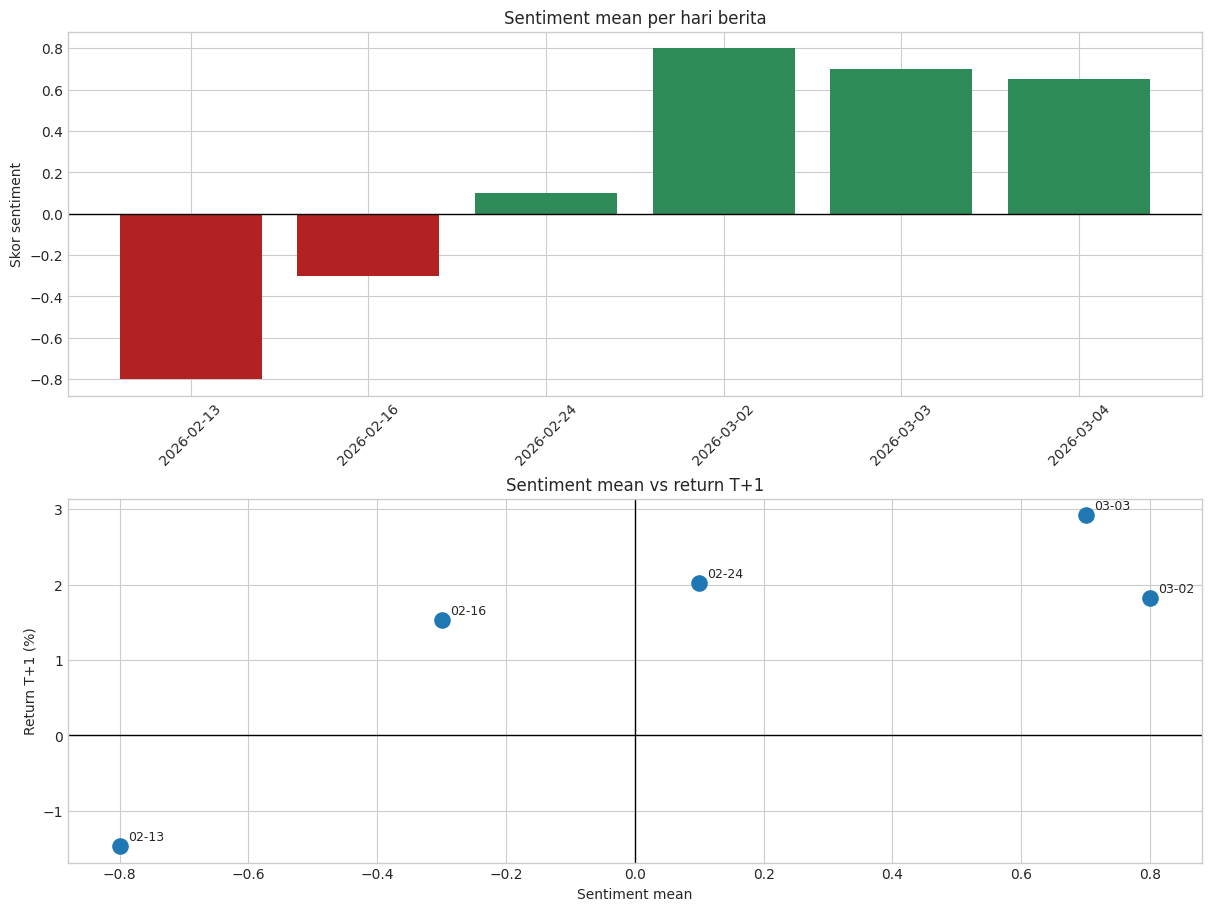

In [6]:
plot_df = evaluation.dropna(subset=['anchor_trade_date']).copy()
plot_df = plot_df.sort_values('news_date')

fig, axes = plt.subplots(2, 1, figsize=(12, 9), constrained_layout=True)

axes[0].bar(plot_df['news_date'].dt.strftime('%Y-%m-%d'), plot_df['market_sentiment_mean'], color=['#2E8B57' if x > 0 else '#B22222' if x < 0 else '#808080' for x in plot_df['market_sentiment_mean']])
axes[0].set_title('Sentiment mean per hari berita')
axes[0].set_ylabel('Skor sentiment')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].tick_params(axis='x', rotation=45)

t1_plot = plot_df.dropna(subset=['ret_t1_pct']).copy()
axes[1].scatter(t1_plot['market_sentiment_mean'], t1_plot['ret_t1_pct'], s=120, color='#1f77b4')
for _, row in t1_plot.iterrows():
    axes[1].annotate(row['news_date'].strftime('%m-%d'), (row['market_sentiment_mean'], row['ret_t1_pct']), xytext=(6, 4), textcoords='offset points', fontsize=9)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Sentiment mean vs return T+1')
axes[1].set_xlabel('Sentiment mean')
axes[1].set_ylabel('Return T+1 (%)')

plt.show()


In [7]:
detail = evaluation[[
    'news_date', 'anchor_trade_date', 'news_count_model', 'market_sentiment_mean',
    'market_sentiment_sum', 'bullish_ratio', 'bearish_ratio',
    'ret_t1_pct', 'ret_t3_pct', 'ret_t5_pct'
]].copy()

def short_read(row: pd.Series) -> str:
    if pd.isna(row['ret_t1_pct']):
        return 'Belum ada harga masa depan untuk dinilai.'
    if row['market_sentiment_mean'] > 0 and row['ret_t1_pct'] > 0:
        return 'Sentiment bullish dan return T+1 ikut naik.'
    if row['market_sentiment_mean'] < 0 and row['ret_t1_pct'] < 0:
        return 'Sentiment bearish dan return T+1 ikut turun.'
    if row['market_sentiment_mean'] == 0:
        return 'Sentiment netral, jadi arah harga sulit disimpulkan.'
    return 'Sentiment dan return T+1 tidak searah.'

detail['pembacaan_singkat'] = detail.apply(short_read, axis=1)
display(detail.rename(columns={
    'news_date': 'Tanggal berita',
    'anchor_trade_date': 'Tanggal acuan trading',
    'news_count_model': 'Jumlah berita model',
    'market_sentiment_mean': 'Sentiment mean',
    'market_sentiment_sum': 'Sentiment sum',
    'bullish_ratio': 'Rasio bullish',
    'bearish_ratio': 'Rasio bearish',
    'ret_t1_pct': 'Return T+1 (%)',
    'ret_t3_pct': 'Return T+3 (%)',
    'ret_t5_pct': 'Return T+5 (%)',
    'pembacaan_singkat': 'Pembacaan singkat',
} ))


,Tanggal berita,Tanggal acuan trading,Jumlah berita model,Sentiment mean,Sentiment sum,Rasio bullish,Rasio bearish,Return T+1 (%),Return T+3 (%),Return T+5 (%),Pembacaan singkat
0,2026-02-13,2026-02-13,1,-0.80,-0.8,0.0,1.0,-1.467297,-0.770952,-0.033159,Sentiment bearish dan return T+1 ikut turun.
1,2026-02-16,2026-02-17,1,-0.30,-0.3,0.0,1.0,1.531213,1.691065,1.657412,Sentiment dan return T+1 tidak searah.
2,2026-02-24,2026-02-24,1,0.10,0.1,0.0,0.0,2.019366,0.777952,4.800132,Sentiment bullish dan return T+1 ikut naik.
3,2026-03-02,2026-03-02,1,0.80,0.8,1.0,0.0,1.817158,NaN,NaN,Sentiment bullish dan return T+1 ikut naik.
4,2026-03-03,2026-03-03,1,0.70,0.7,1.0,0.0,2.921898,NaN,NaN,Sentiment bullish dan return T+1 ikut naik.
5,2026-03-04,2026-03-04,2,0.65,1.3,1.0,0.0,NaN,NaN,NaN,Belum ada harga masa depan untuk dinilai.
6,2026-03-09,NaT,1,0.80,0.8,1.0,0.0,NaN,NaN,NaN,Belum ada harga masa depan untuk dinilai.


## Kesimpulan Praktis

**Yang bisa disimpulkan sekarang**
- Pipeline sentiment **sudah jalan** dari retrieval -> scoring -> agregasi harian.
- Hasil artikel yang lolos terlihat **masuk akal secara bisnis**: banyak membahas supply disruption, logistics, dan policy.
- Validasi terhadap return harga **baru level pilot**, karena jumlah hari yang bisa diuji masih sangat sedikit.

**Peran yang paling masuk akal saat ini**
- **Explanation:** layak dipakai sekarang
- **Overlay jangka pendek:** layak diuji lebih lanjut
- **Feature utama model:** belum layak, karena sample terlalu pendek

**Kriteria agar next step lebih kuat**
- jumlah hari sentiment historis harus jauh lebih panjang
- scoring harus konsisten pada berita bullish, bearish, dan netral
- perlu uji apakah sentiment membantu di hari event, bukan di semua hari
